In [1]:
# Imports
import os
import torch
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from torchvision import transforms
from torchvision.models import resnet50, ResNet50_Weights
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

In [2]:
# Functions
def preprocess_image(image):
        preprocess = transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406],
                             std=[0.229, 0.224, 0.225])
                             ])
        return preprocess(image)

In [3]:
# Load ResNet50 ImageNet
try:
    modelI = resnet50(weights=ResNet50_Weights.IMAGENET1K_V1)
    modelI = torch.nn.Sequential(*(list(modelI.children())[:-1]))
    print("ResNet50 (ImageNet) loaded successfully")
except Exception as e:
    print(f"Error loading ResNet50 (ImageNet): {e}")

modelI.eval()

# Load ResNet50 PlantNet
try:
    num_classes = 1081
    resnet_checkpoint_path = 'models/resnet50_weights_best_acc.tar'
    checkpoint = torch.load(resnet_checkpoint_path, map_location='cpu')
    state_dict = checkpoint["model"]
    
    modelP = resnet50(num_classes=num_classes)
    modelP.load_state_dict(state_dict=state_dict, strict=True)
    modelP = torch.nn.Sequential(*(list(modelP.children())[:-1]))
    print("ResNet50 (PlantNet) loaded successfully")
except Exception as e:
    print(f"Error loading ResNet50 (PlantNet): {e}")

modelP.eval()

ResNet50 (ImageNet) loaded successfully
ResNet50 (PlantNet) loaded successfully


Sequential(
  (0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (2): ReLU(inplace=True)
  (3): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (4): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)


In [4]:
# Embedding space
dataset1 = "data/frames/biodiverse/"
frames1 = os.listdir(dataset1)
dataset2 = "data/frames/grass/"
frames2 = os.listdir(dataset2)

embeddings = []
labels = []

for frame in frames1:
    img = Image.open(dataset1 + frame)
    preprocessed_img = preprocess_image(img)
    input_tensor = preprocessed_img.unsqueeze(0)
    with torch.no_grad():
        features1 = modelI(input_tensor)
        features2 = modelP(input_tensor)
    embeddings.append(features1.cpu().numpy().flatten())
    labels.append("red")
    embeddings.append(features2.cpu().numpy().flatten())
    labels.append("blue")

for frame in frames2:
    img = Image.open(dataset2 + frame)
    preprocessed_img = preprocess_image(img)
    input_tensor = preprocessed_img.unsqueeze(0)
    with torch.no_grad():
        features1 = modelI(input_tensor)
        features2 = modelP(input_tensor)
    embeddings.append(features1.cpu().numpy().flatten())
    labels.append("red")
    embeddings.append(features2.cpu().numpy().flatten())
    labels.append("blue")

embeddingspace = np.array(embeddings)

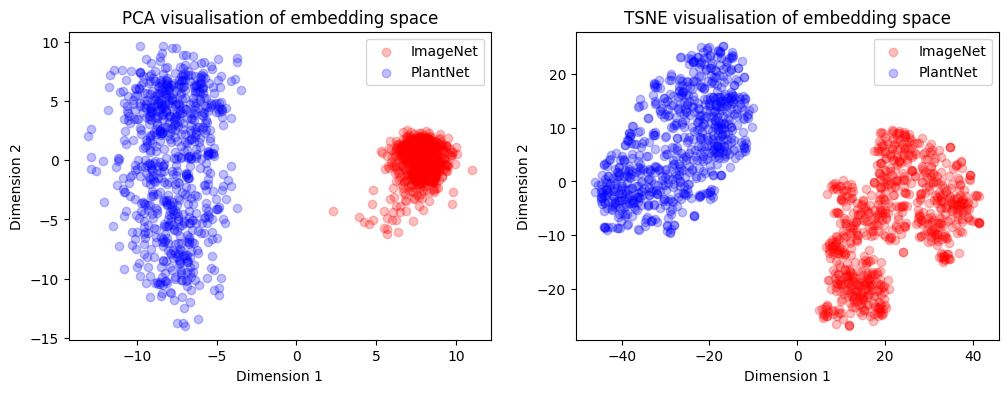

In [9]:
# Visualisation
pca = PCA(n_components=2, random_state=42)
pca_results = pca.fit_transform(embeddingspace)

tsne = TSNE(n_components=2, perplexity=50, random_state=42)
tsne_results = tsne.fit_transform(embeddingspace)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

color_map = {
    "red": "ImageNet",
    "blue": "PlantNet"
}

# PCA plot
for color, model_name in color_map.items():
    idxs = [i for i, lbl in enumerate(labels) if lbl == color]
    axes[0].scatter(
        pca_results[idxs, 0],
        pca_results[idxs, 1],
        c=color,
        alpha=0.25,
        label=model_name
    )
axes[0].set_title("PCA visualisation of embedding space")
axes[0].set_xlabel("Dimension 1")
axes[0].set_ylabel("Dimension 2")
axes[0].legend()

# t-SNE plot
for color, model_name in color_map.items():
    idxs = [i for i, lbl in enumerate(labels) if lbl == color]
    axes[1].scatter(
        tsne_results[idxs, 0],
        tsne_results[idxs, 1],
        c=color,
        alpha=0.25,
        label=model_name
    )
axes[1].set_title("TSNE visualisation of embedding space")
axes[1].set_xlabel("Dimension 1")
axes[1].set_ylabel("Dimension 2")
axes[1].legend()

plt.show()